In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import chi2
from sklearn.mixture import GaussianMixture

# Classificador

In [2]:
def matriz_conf(y_true, y_pred, labels):
    total_labels = labels
    print(total_labels)
    cm = np.zeros((len(total_labels),len(total_labels)), dtype=int)
    for i in range(len(y_true)):
        cm[y_true[i]][y_pred[i]] += 1
    
    cm = pd.DataFrame(cm, columns=total_labels, index=total_labels)

    cm_transp = pd.DataFrame(np.transpose(cm.to_numpy()), columns=total_labels, index=total_labels)

    for c in cm_transp.columns:
        cm_transp[c] = cm_transp[c]/cm_transp[c].sum()

    cm_porcento = pd.DataFrame(np.transpose(cm_transp.to_numpy()), columns=total_labels, index=total_labels)

    return cm, cm_porcento

def acc(cm, hidden_classes):
    cm_transp = pd.DataFrame(np.transpose(cm.dropna().to_numpy()), columns=cm.columns, index=cm.columns)
    acc = 0
    total = 0
    for c in cm_transp.columns:
        if c not in hidden_classes:
            acc += cm_transp[c][c]
        else:
            acc += cm_transp[c][-1]
        total += cm_transp[c].sum()
    return acc/total

# Calcula CM para todos

In [3]:
filenames = [0,2,3,4,5]

labels_str = ['DDoS', 'Benign', 'DoS', 'BruteForce', 'Bot', 'Web']

filenames

# pd.set_option('future.no_silent_downcasting', True)

[0, 2, 3, 4, 5]

0


Label
1    514148
2    329224
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


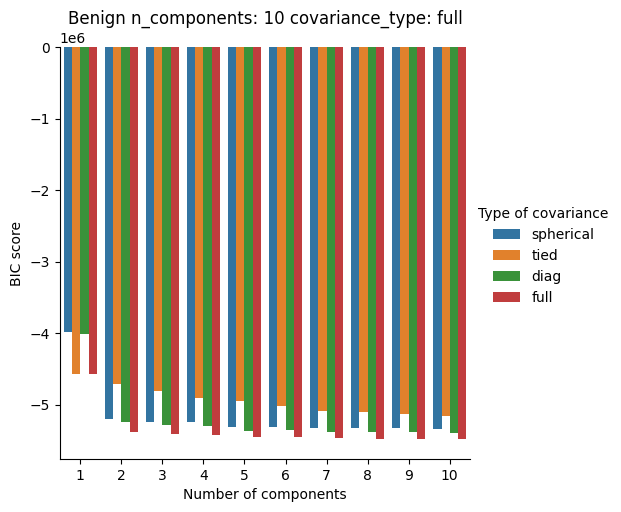

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


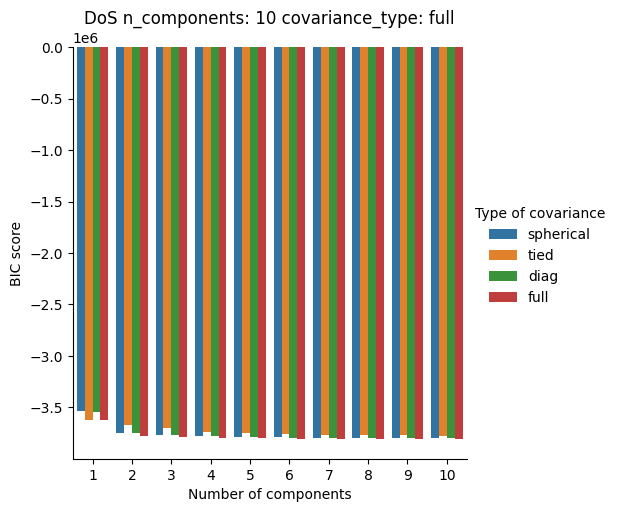

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 9 covariance_type: full


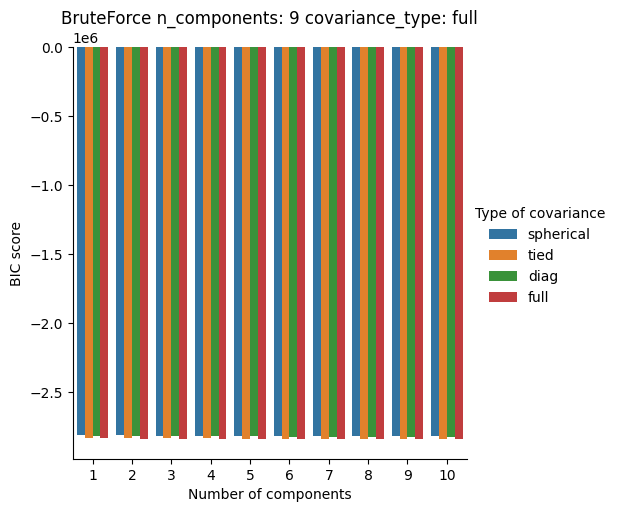

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


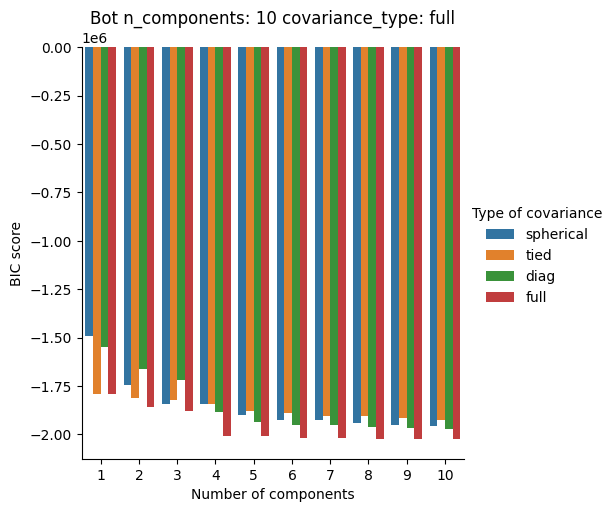

Tipo: 5 = Web
Melhor modelo: n_componentes: 5 covariance_type: full


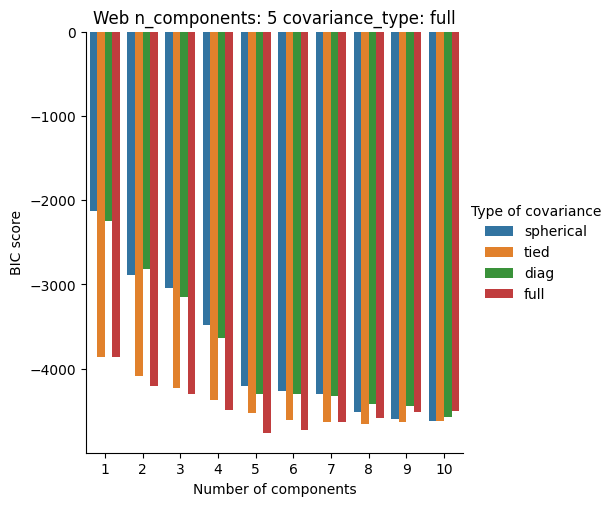

,0,1,2,3,4,5
0,NaN,16.850018,-22.017862,-84.845299,11.130449,-7.451370
1,NaN,10.107118,29.558396,3.764206,-20.368219,-20.718955
2,NaN,28.087941,-21.987187,-104.466465,12.850944,5.413376
3,NaN,-0.579248,-60.176279,29.382772,-93.092408,-60.408337
4,NaN,28.276247,-17.960589,-107.304933,12.884881,9.675765
...,...,...,...,...,...,...
519951,NaN,27.150737,-19.070934,-111.910677,12.783652,7.521907
519952,NaN,8.693385,-329.023867,-268.268543,29.120218,16.365900
519953,NaN,12.643786,-18.884799,-94.449302,12.212926,1.739684
519954,NaN,27.653856,-13.183161,-99.978905,12.546362,11.256006


,0,1,2,3,4,5
0,NaN,12.579709,-26.375391,-94.939753,12.493856,2.625676
1,NaN,16.571408,-21.529027,-82.848289,11.023212,-7.914170
2,NaN,27.819825,-21.183423,-99.289947,12.831223,4.724325
3,NaN,27.996430,-19.093017,-103.768552,12.838739,7.177657
4,NaN,12.453616,-44.138100,-138.136972,7.015844,-23.087253
...,...,...,...,...,...,...
649942,NaN,28.245519,-18.000897,-106.216505,12.916805,9.248830
649943,NaN,9.581226,-202.529740,-306.556090,-0.002969,7.191309
649944,NaN,10.355444,-158.126833,-262.445348,1.481682,13.318332
649945,NaN,-0.545817,-60.734298,29.435787,-94.450154,-61.583972


2


Label
0    808919
1    514148
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


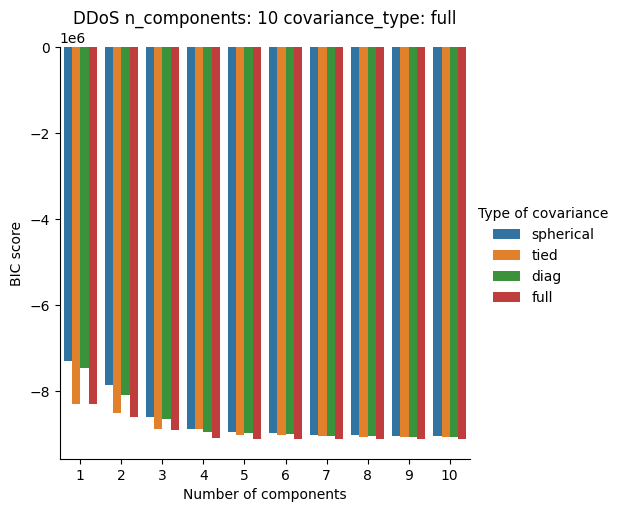

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


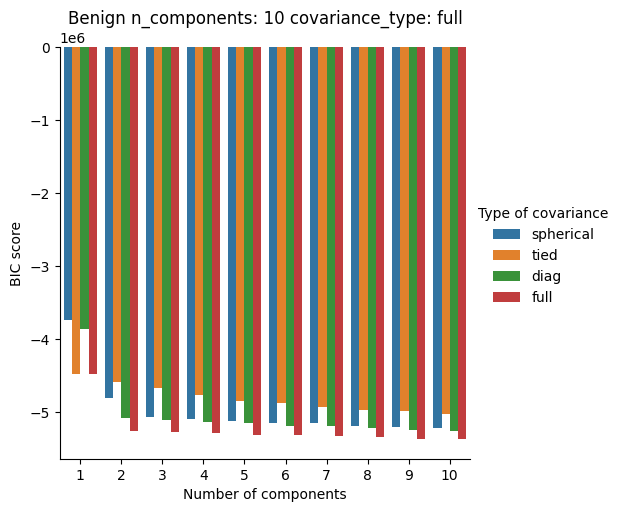

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 2 covariance_type: full


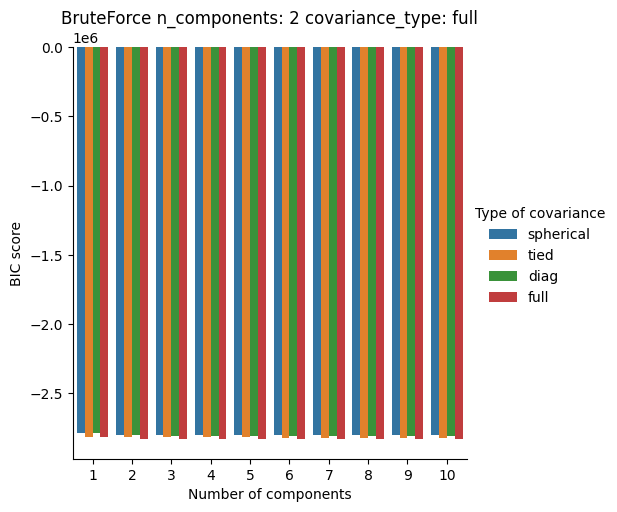

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


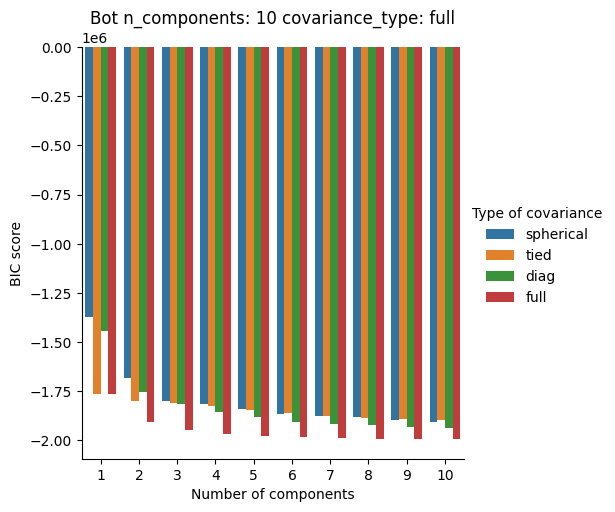

Tipo: 5 = Web
Melhor modelo: n_componentes: 8 covariance_type: full


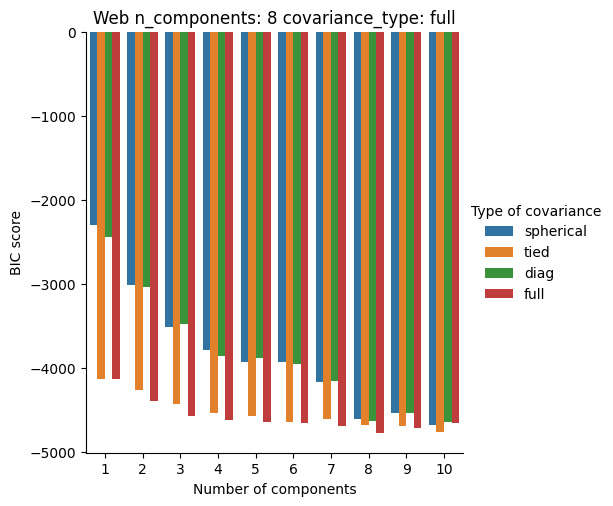

,0,1,2,3,4,5
0,28.539526,9.731768,NaN,-5632.925941,5.746143,13.053284
1,-87.306051,18.790705,NaN,-4074.965495,11.290977,-37.261327
2,-69.410708,27.359307,NaN,-4268.244276,11.635125,12.721473
3,-229.716807,-4.507887,NaN,29.212008,-203.008313,-79.844879
4,-65.256310,27.629190,NaN,-4268.172099,4.333930,-0.953788
...,...,...,...,...,...,...
519951,-66.839058,27.551724,NaN,-4192.969134,10.157769,6.845111
519952,-119.267127,11.915353,NaN,-12874.543210,28.895640,20.667601
519953,28.588092,9.816882,NaN,-5567.822700,5.872829,12.982779
519954,-67.056807,27.986694,NaN,-4249.415606,8.927384,6.324228


,0,1,2,3,4,5
0,28.789752,9.852976,NaN,-5587.190815,5.969504,13.105587
1,28.499884,9.705632,NaN,-5639.829570,5.689463,12.495355
2,-73.401933,25.758916,NaN,-4311.328448,9.792786,8.476058
3,-74.190610,25.144268,NaN,-4347.890285,10.242224,9.911036
4,27.746792,9.870631,NaN,-5698.769578,5.495394,10.718581
...,...,...,...,...,...,...
649942,-65.003619,27.643750,NaN,-4256.833448,4.407504,-1.243175
649943,27.838967,9.862232,NaN,-5691.732842,5.472193,10.891140
649944,27.853583,9.869783,NaN,-5688.177315,5.471349,10.991221
649945,-222.855317,-4.267850,NaN,29.300193,-203.422425,-78.071756


3


Label
0    808919
1    514148
2    329224
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


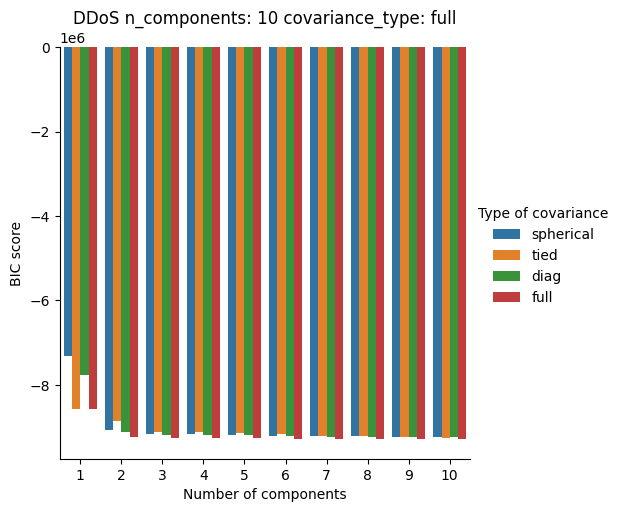

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


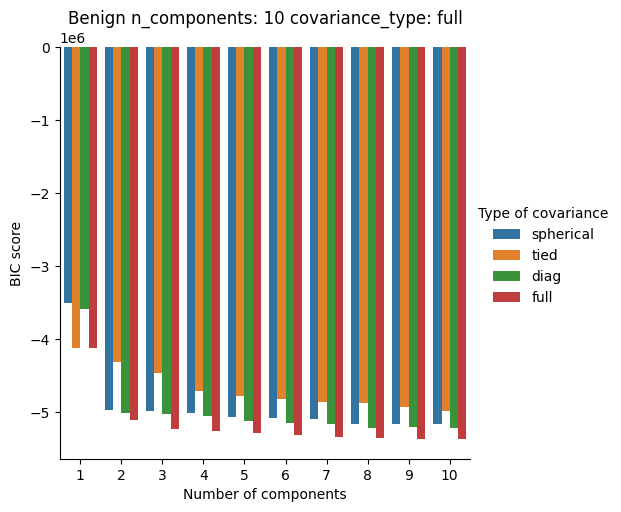

Tipo: 2 = DoS
Melhor modelo: n_componentes: 9 covariance_type: full


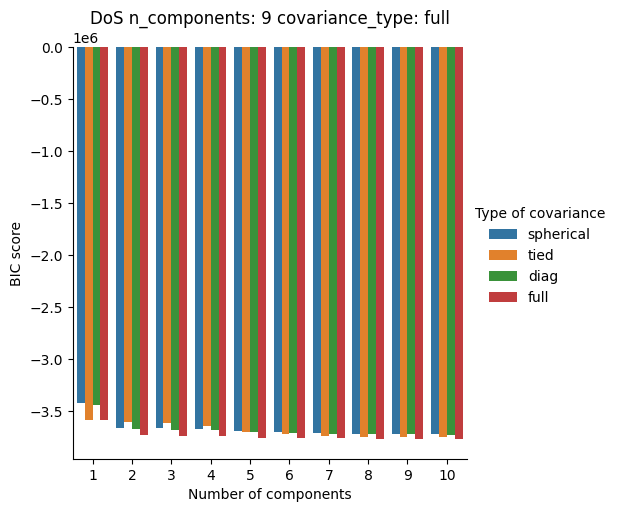

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


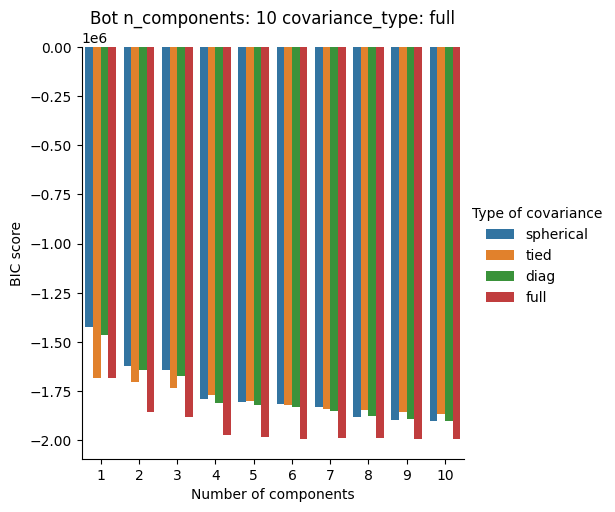

Tipo: 5 = Web
Melhor modelo: n_componentes: 5 covariance_type: full


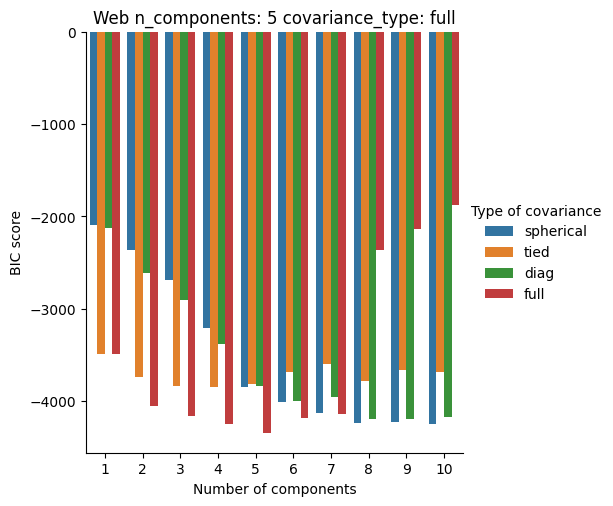

,0,1,2,3,4,5
0,28.742079,3.161502,-676.173837,NaN,1.719787,13.583405
1,-615.507106,-65.868004,29.214965,NaN,-947.594001,-163.866251
2,-21.451928,26.778201,-61.110811,NaN,6.984075,7.419889
3,-237.940124,0.110965,7.460234,NaN,-358.468859,-19.681144
4,-15.756825,27.449389,-82.446924,NaN,6.360943,9.249187
...,...,...,...,...,...,...
519951,-22.426957,26.540065,-58.385021,NaN,9.765126,5.990715
519952,-7070.189246,8.985720,-5661.194399,NaN,28.913687,14.831221
519953,29.192790,3.422273,-649.923009,NaN,2.583751,13.243017
519954,-14.748278,27.341883,-73.952898,NaN,8.014249,8.063789


,0,1,2,3,4,5
0,29.124088,3.492423,-646.823030,NaN,2.722883,13.307396
1,28.707603,3.121632,-678.352956,NaN,1.655699,13.502630
2,-19.586206,25.261361,-61.014786,NaN,10.975713,4.621542
3,-24.773092,25.872593,-56.848020,NaN,6.192483,7.148243
4,28.455666,3.749016,-636.052917,NaN,1.528582,13.460435
...,...,...,...,...,...,...
649942,-15.834054,27.443225,-82.817048,NaN,6.352912,9.190662
649943,28.350622,3.696822,-637.132946,NaN,1.380952,13.399180
649944,28.380347,3.690518,-637.740357,NaN,1.401150,13.405543
649945,-12.347511,20.270586,-57.976362,NaN,0.987502,3.313479


4


Label
0    808919
1    514148
2    329224
3    243806
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


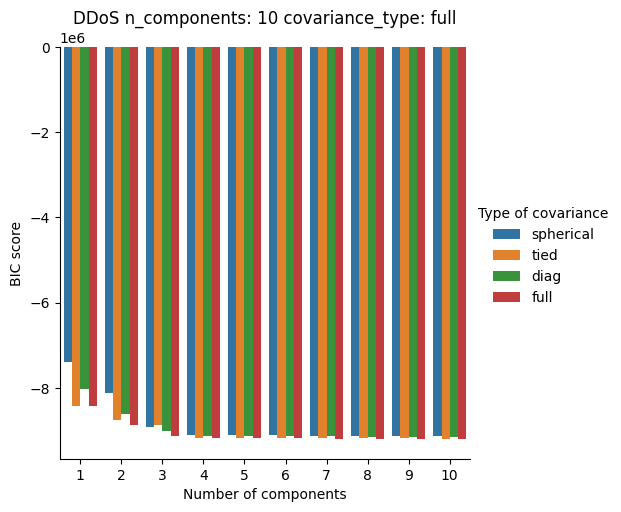

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


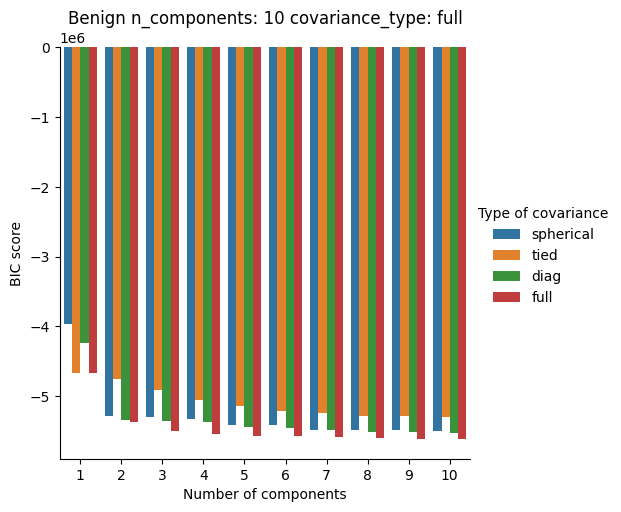

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


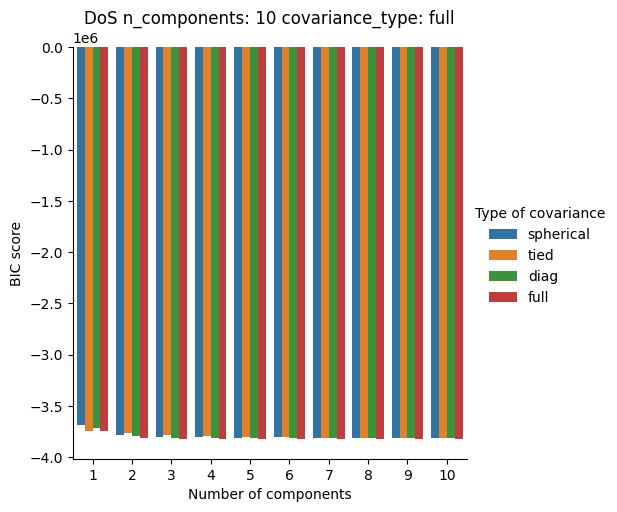

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 7 covariance_type: full


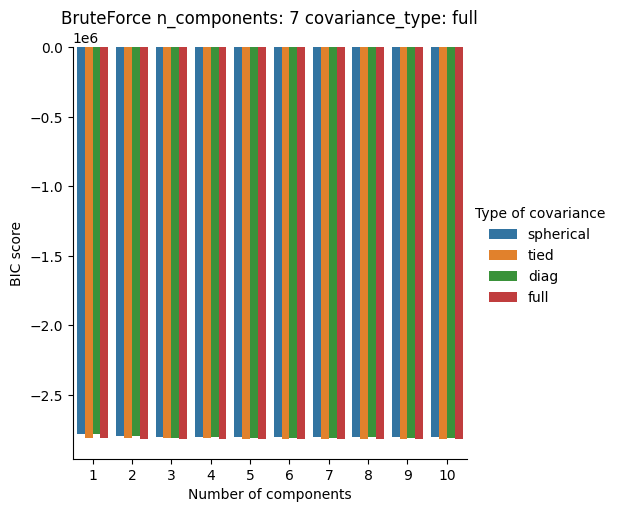

Tipo: 5 = Web
Melhor modelo: n_componentes: 3 covariance_type: full


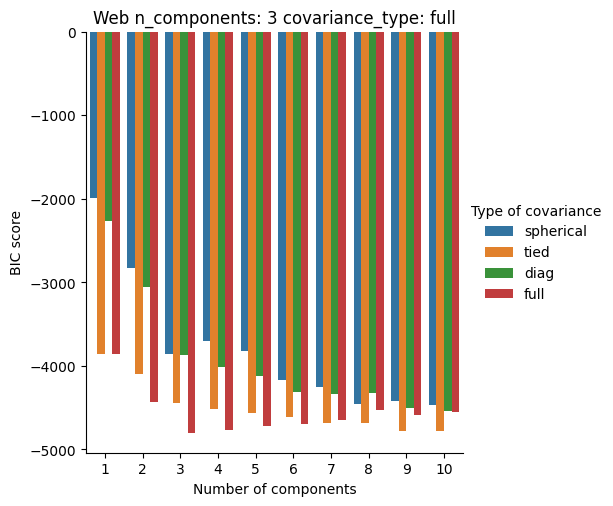

,0,1,2,3,4,5
0,28.416014,9.054079,-168.069593,-2811.913614,NaN,-6.207258
1,-850.879300,14.609580,29.497977,4.677095,NaN,-30.860539
2,-38.457867,28.166507,-26.753238,-863.137165,NaN,0.228296
3,-3094.082384,-4.625077,-146.112324,28.991238,NaN,-28.462272
4,-37.523315,28.655305,-24.608242,-854.565281,NaN,1.176066
...,...,...,...,...,...,...
519951,-38.706022,28.492576,-25.677200,-857.729186,NaN,0.894461
519952,-37.951326,26.342565,-29.275799,-903.498772,NaN,-0.625001
519953,28.920248,9.126839,-168.001467,-2856.636289,NaN,-5.989036
519954,-38.498821,27.742557,-23.580865,-849.416067,NaN,-0.160449


,0,1,2,3,4,5
0,28.910669,9.146822,-167.518678,-2849.110518,NaN,-5.930787
1,28.421203,9.055352,-168.089330,-2812.142057,NaN,-6.183490
2,-36.818743,28.363493,-26.698379,-873.979680,NaN,0.211391
3,-35.905315,28.340070,-27.166710,-872.307053,NaN,1.603792
4,28.325834,8.884582,-171.590577,-2872.547164,NaN,-7.291997
...,...,...,...,...,...,...
649942,-37.555321,28.652873,-24.498700,-855.138053,NaN,0.863505
649943,28.336612,8.881655,-171.649518,-2873.507408,NaN,-7.272184
649944,28.325370,8.885512,-171.569191,-2872.608132,NaN,-7.290141
649945,-3144.486871,-4.530739,-154.030060,29.142451,NaN,-28.757491


5


Label
0    808919
1    514148
2    329224
3    243806
4    183163
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 8 covariance_type: full


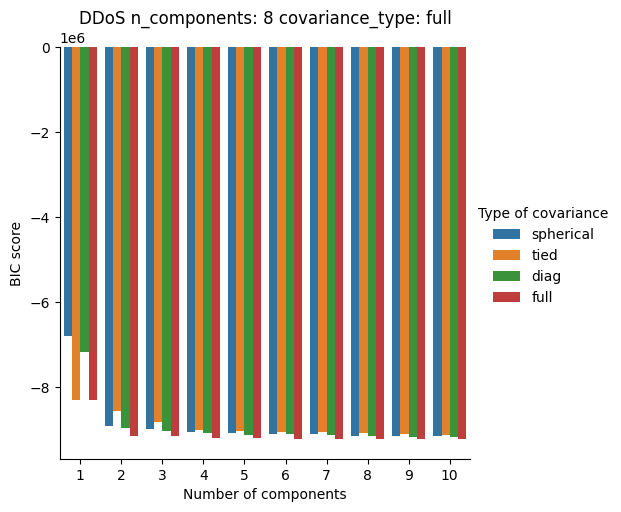

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


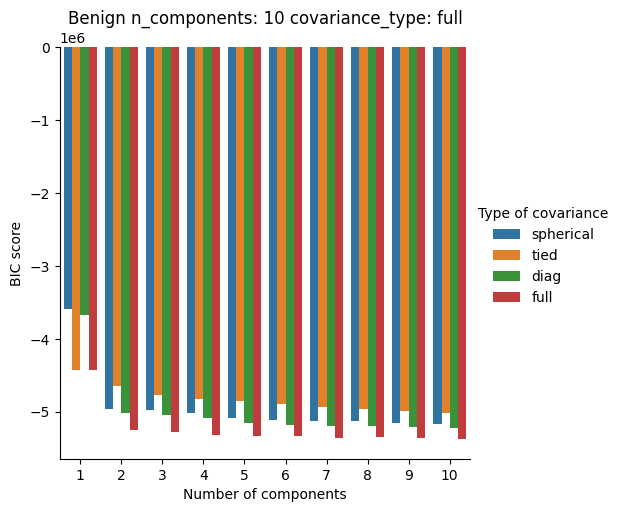

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: spherical


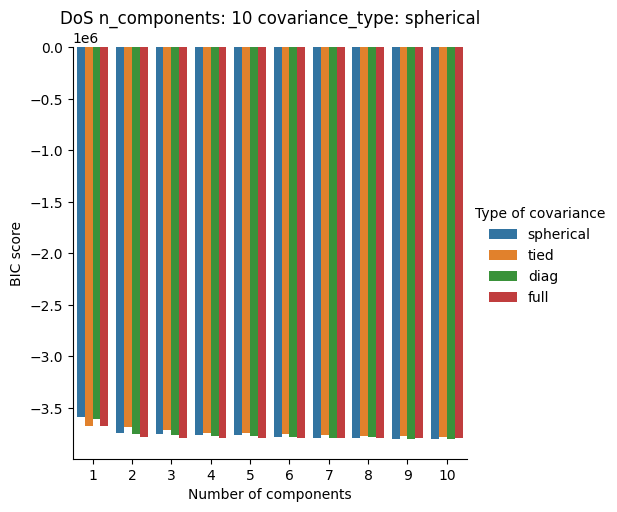

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 3 covariance_type: full


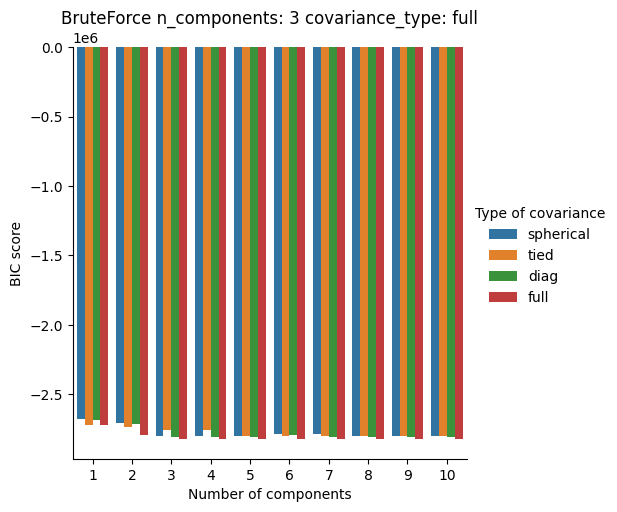

Tipo: 4 = Bot
Melhor modelo: n_componentes: 9 covariance_type: full


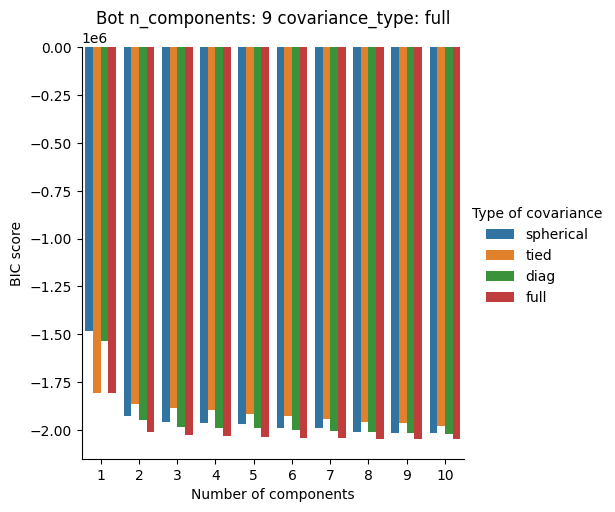

,0,1,2,3,4,5
0,28.688702,10.668192,-433.054663,-10007.951821,10.556185,NaN
1,-455.344070,15.138315,29.566266,17.535984,-151.787078,NaN
2,-53.139937,27.181764,-75.817836,-1329.734832,6.578241,NaN
3,-496.581126,4.618524,-480.037218,28.692260,-134.829496,NaN
4,-46.188029,27.490122,-75.719280,-1331.942425,7.043588,NaN
...,...,...,...,...,...,...
519951,-54.019144,27.369716,-74.652657,-1287.170824,6.041404,NaN
519952,-411.128246,13.217599,-176.794923,-10726.408396,28.629665,NaN
519953,28.999271,12.564762,-431.709981,-9959.970745,13.237844,NaN
519954,-49.171335,27.360828,-75.606266,-1256.365325,3.444926,NaN


,0,1,2,3,4,5
0,28.678611,12.999062,-429.349879,-9928.162748,13.545262,NaN
1,28.646420,10.600683,-433.271525,-10015.512954,10.446994,NaN
2,-52.001808,25.174534,-77.637521,-1306.072698,6.207895,NaN
3,-55.324340,24.526510,-73.539846,-1315.163349,6.088289,NaN
4,27.619081,10.550437,-428.298250,-9917.578434,11.401817,NaN
...,...,...,...,...,...,...
649942,-46.195854,27.491693,-75.681227,-1329.420216,7.052925,NaN
649943,28.383109,10.506635,-430.217619,-9973.207157,10.756284,NaN
649944,28.499102,10.502625,-430.649468,-9983.610572,10.666439,NaN
649945,-500.894082,4.667769,-477.257175,29.290770,-138.120576,NaN


In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import os

def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": range(1, 11),
    "covariance_type": ["spherical", "tied", "diag", "full"],
    "random_state": [123],
}

exp_train = []
exp_val = []
exp_test = []
y_true_all_exp_train = []
y_true_all_exp_val = []
y_true_all_exp_test = []
for z in range(len(filenames)):
    
    train_encoded_df = pd.read_csv(f'train_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    val_encoded_df = pd.read_csv(f'val_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    test_encoded_df = pd.read_csv(f'test_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    y_true_all_exp_train.append(train_encoded_df['Label'].values.tolist())
    y_true_all_exp_val.append(val_encoded_df['Label'].values.tolist())
    y_true_all_exp_test.append(test_encoded_df['Label'].values.tolist())
    print(filenames[z])
    hidden_classes = [filenames[z]] # Classes ocultas do treinamento
    for i in range(len(labels_str)):
        train_encoded_df['Label'] = train_encoded_df['Label'].replace(labels_str[i],i)
        val_encoded_df['Label'] = val_encoded_df['Label'].replace(labels_str[i],i)
        test_encoded_df['Label'] = test_encoded_df['Label'].replace(labels_str[i],i)

    display(train_encoded_df['Label'].value_counts())
        
    
        
    gmms = []
    for i in range(len(labels_str)):
        if i not in hidden_classes:
            print(f'Tipo: {i} = {labels_str[i]}')
            grid_search = GridSearchCV(
                GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
            )
            grid_search.fit(train_encoded_df[train_encoded_df['Label'] == i].drop(columns=['Label']).to_numpy())
            print(f"Melhor modelo: n_componentes: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            gmms.append(grid_search.best_estimator_)
            df = pd.DataFrame(grid_search.cv_results_)[
                ["param_n_components", "param_covariance_type", "mean_test_score"]
            ]
            df["mean_test_score"] = -df["mean_test_score"]
            df = df.rename(
                columns={
                    "param_n_components": "Number of components",
                    "param_covariance_type": "Type of covariance",
                    "mean_test_score": "BIC score",
                }
            )
            df.sort_values(by="BIC score").head()
            sns.catplot(
                data=df,
                kind="bar",
                x="Number of components",
                y="BIC score",
                hue="Type of covariance",
                
            ).set(title = f"{labels_str[i]} n_components: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            plt.show()
            # plt.savefig(f'class_{i}_train_{filenames[z]}_GMM_BIC_1_10_scores.png')
        else:
            gmms.append(None)
    
    # scores = []
    # for i, row in train_encoded_df.drop(columns=['Label']).iterrows():
    #     max_dist = -np.inf
    #     pred = -1
    #     scores.append([])
    #     for j in range(len(labels_str)):
    #         if j not in hidden_classes:
    #             inside = False
    #             max = -np.inf
    #             # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
    #             score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
    #             scores[i].append(score)
    #         else:
    #             scores[i].append(np.nan)
    
    
    # display(pd.DataFrame(scores))
    # exp_train.append(scores)
    #pd.DataFrame(scores).to_csv(f'train_{filenames[z]}_GMM_BIC_1_10_scores.csv',index=False)

    scores = []
    for i, row in val_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_val.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = val_encoded_df["Label"].values
    scores_df.to_csv(f'val_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)

    scores = []
    for i, row in test_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_test.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = test_encoded_df["Label"].values
    scores_df.to_csv(f'test_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)